# Dự đoán Giá Nhà Việt Nam — Hồi quy với Học máy Truyền thống

Notebook này thực hiện 4 yêu cầu:
1. Xây dựng 3 biểu đồ phân phối
2. Xây dựng 5 mô hình học máy
3. Thử nghiệm, đánh giá 5 mô hình bằng 5 độ đo và rút ra mô hình tốt nhất
4. Triển khai mô hình qua ứng dụng `app.py`

**Bài toán:** Dự đoán `Price` (giá nhà, đơn vị: tỷ VNĐ) từ các đặc trưng bất động sản
(diện tích, mặt tiền, đường vào, số tầng, số phòng ngủ/phòng tắm, hướng nhà, pháp lý, nội thất, khu vực).
Đây là bài toán **hồi quy** (regression) vì mục tiêu là một giá trị số liên tục.


## 0. Nạp và khám phá dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('vietnam_housing_dataset.csv')
print("Kích thước dữ liệu (dòng, cột):", df.shape)
df.head()


Kích thước dữ liệu (dòng, cột): (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 2.8 MB


In [3]:
print("Số giá trị thiếu theo từng cột:")
print(df.isnull().sum().sort_values(ascending=False))


Số giá trị thiếu theo từng cột:
Balcony direction    24983
House direction      21239
Furniture state      14119
Access Road          13297
Frontage             11564
Bathrooms             7074
Bedrooms              5162
Legal status          4506
Floors                3603
Area                     0
Address                  0
Price                    0
dtype: int64


Nhận xét: một số cột có tỷ lệ thiếu khá cao (`Balcony direction`, `House direction`, `Access Road`,
`Frontage`, `Furniture state`). Ta sẽ xử lý bằng cách:
- Cột số (`Area`, `Frontage`, `Access Road`, `Floors`, `Bedrooms`, `Bathrooms`): điền giá trị thiếu bằng
  **trung vị (median)**.
- Cột phân loại (`House direction`, `Balcony direction`, `Legal status`, `Furniture state`): điền giá trị
  thiếu bằng nhãn `"Unknown"` (coi thiếu thông tin là một loại thông tin riêng).
- Cột `Address`: trích xuất **tỉnh/thành phố** (thành phần cuối cùng của địa chỉ) làm đặc trưng khu vực.


In [4]:
df['Price'].describe()


count    30229.000000
mean         5.872078
std          2.211877
min          1.000000
25%          4.200000
50%          5.900000
75%          7.500000
max         11.500000
Name: Price, dtype: float64

## 1. Ba biểu đồ phân phối

### Biểu đồ 1: Phân phối giá nhà (Price)

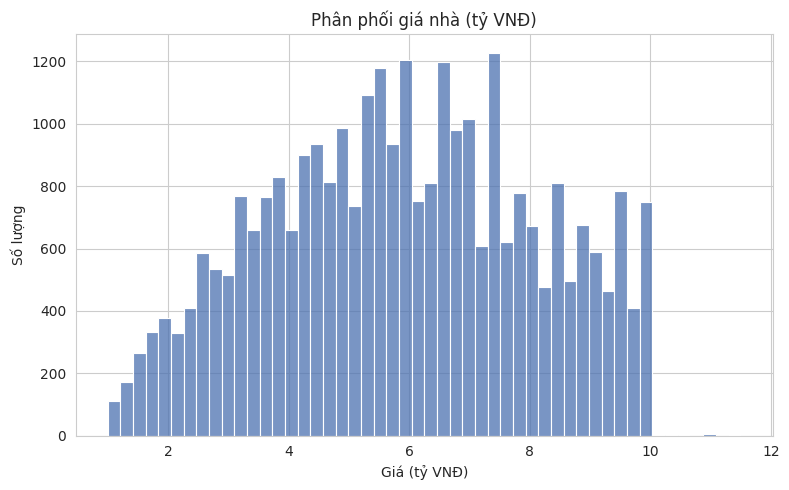

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(data=df, x='Price', bins=50, color='#4C72B0', ax=ax)
ax.set_title('Phân phối giá nhà (tỷ VNĐ)')
ax.set_xlabel('Giá (tỷ VNĐ)')
ax.set_ylabel('Số lượng')
plt.tight_layout()
plt.savefig('dist1_price.png', dpi=110)
plt.show()


**Nhận xét:** Giá nhà tập trung nhiều trong khoảng 3–8 tỷ VNĐ, phân phối lệch phải nhẹ, với một
đỉnh rõ ở mốc 10 tỷ (có thể do dữ liệu bị chặn/gộp ở ngưỡng trên).

### Biểu đồ 2: Phân phối diện tích (Area)

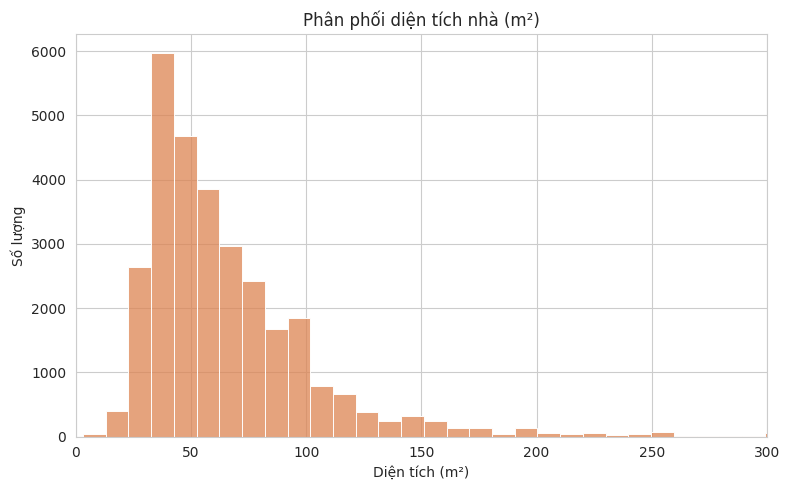

In [6]:
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(data=df, x='Area', bins=60, color='#DD8452', ax=ax)
ax.set_xlim(0, 300)
ax.set_title('Phân phối diện tích nhà (m²)')
ax.set_xlabel('Diện tích (m²)')
ax.set_ylabel('Số lượng')
plt.tight_layout()
plt.savefig('dist2_area.png', dpi=110)
plt.show()


**Nhận xét:** Đa số nhà có diện tích trong khoảng 30–100 m², với đỉnh phân phối quanh 40–60 m²,
phù hợp với đặc điểm nhà phố/nhà ống phổ biến ở Việt Nam.

### Biểu đồ 3: Phân phối số phòng ngủ (Bedrooms)

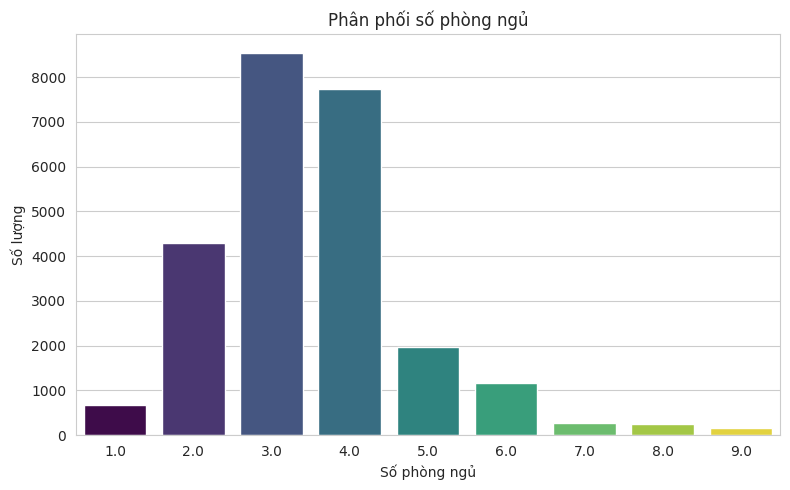

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
sns.countplot(data=df, x='Bedrooms', hue='Bedrooms', palette='viridis', legend=False, ax=ax)
ax.set_title('Phân phối số phòng ngủ')
ax.set_xlabel('Số phòng ngủ')
ax.set_ylabel('Số lượng')
plt.tight_layout()
plt.savefig('dist3_bedrooms.png', dpi=110)
plt.show()


**Nhận xét:** Phần lớn nhà có 3–4 phòng ngủ, phản ánh quy mô nhà ở phổ biến dành cho hộ gia đình
tại các đô thị Việt Nam.


## Tiền xử lý & Biểu diễn đặc trưng (Feature Representation)

Trước khi xây mô hình, ta cần chuyển dữ liệu thô thành ma trận đặc trưng số `X` và biến mục tiêu `y`.


In [8]:
df_model = df.copy()

# Trích xuất khu vực (tỉnh/thành phố) từ địa chỉ, chuẩn hóa khoảng trắng và dấu chấm cuối
df_model['city'] = (
    df_model['Address'].str.split(',').str[-1]
    .str.strip().str.rstrip('.').str.strip()
)

# Gộp các thành phố hiếm thành 'Khac' để tránh one-hot quá nhiều cột
top_cities = df_model['city'].value_counts().nlargest(15).index
df_model['city'] = df_model['city'].where(df_model['city'].isin(top_cities), 'Khac')

print("Số khu vực sau khi gộp:", df_model['city'].nunique())
print(df_model['city'].value_counts())


Số khu vực sau khi gộp: 16
city
Hồ Chí Minh        11778
Hà Nội             10457
Bình Dương          1672
Đà Nẵng             1437
Khac                 907
Đồng Nai             829
Hải Phòng            789
Khánh Hòa            743
Hưng Yên             405
Long An              339
Bà Rịa Vũng Tàu      240
Bắc Ninh             167
Bình Thuận           127
Lâm Đồng             118
Cần Thơ              111
Quảng Ninh           110
Name: count, dtype: int64


In [9]:
num_cols = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']
cat_cols = ['House direction', 'Balcony direction', 'Legal status', 'Furniture state', 'city']

# Điền giá trị thiếu
for c in num_cols:
    df_model[c] = df_model[c].fillna(df_model[c].median())
for c in cat_cols:
    df_model[c] = df_model[c].fillna('Unknown')

# Loại bỏ các dòng có Price cực đoan (outlier rõ rệt) để mô hình ổn định hơn
df_model = df_model[df_model['Price'] <= df_model['Price'].quantile(0.995)]

X = pd.get_dummies(df_model[num_cols + cat_cols], columns=cat_cols, drop_first=True)
y = df_model['Price']

print("Kích thước ma trận đặc trưng X:", X.shape)
X.head()


Kích thước ma trận đặc trưng X: (30219, 41)


,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,House direction_Nam,House direction_Tây,House direction_Tây - Bắc,House direction_Tây - Nam,House direction_Unknown,House direction_Đông,House direction_Đông - Bắc,House direction_Đông - Nam,Balcony direction_Nam,Balcony direction_Tây,Balcony direction_Tây - Bắc,Balcony direction_Tây - Nam,Balcony direction_Unknown,Balcony direction_Đông,Balcony direction_Đông - Bắc,Balcony direction_Đông - Nam,Legal status_Sale contract,Legal status_Unknown,Furniture state_Full,Furniture state_Unknown,city_Bình Dương,city_Bình Thuận,city_Bắc Ninh,city_Cần Thơ,city_Hà Nội,city_Hưng Yên,city_Hải Phòng,city_Hồ Chí Minh,city_Khac,city_Khánh Hòa,city_Long An,city_Lâm Đồng,city_Quảng Ninh,city_Đà Nẵng,city_Đồng Nai
0,84.0,4.5,6.0,4.0,3.0,3.0,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,60.0,4.5,6.0,5.0,3.0,3.0,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,90.0,6.0,13.0,5.0,3.0,3.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,54.0,4.5,3.5,2.0,2.0,3.0,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,92.0,4.5,6.0,2.0,4.0,4.0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (24175, 41)  Test: (6044, 41)


## 2. Năm mô hình học máy

Ta huấn luyện 5 mô hình hồi quy truyền thống trên cùng một tập dữ liệu huấn luyện:
1. Linear Regression
2. k-Nearest Neighbors Regressor
3. Decision Tree Regressor
4. Random Forest Regressor
5. Gradient Boosting Regressor


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# k-NN cần dữ liệu đã chuẩn hóa vì dựa trên khoảng cách
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": (LinearRegression(), False),
    "k-NN Regressor": (KNeighborsRegressor(n_neighbors=7), True),
    "Decision Tree Regressor": (DecisionTreeRegressor(max_depth=10, random_state=42), False),
    "Random Forest Regressor": (RandomForestRegressor(n_estimators=200, max_depth=14, random_state=42, n_jobs=-1), False),
    "Gradient Boosting Regressor": (GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42), False),
}

trained_models = {}
for name, (model, needs_scaling) in models.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    model.fit(Xtr, y_train)
    trained_models[name] = model
    print(f"Da huan luyen: {name}")


Da huan luyen: Linear Regression
Da huan luyen: k-NN Regressor
Da huan luyen: Decision Tree Regressor


Da huan luyen: Random Forest Regressor


Da huan luyen: Gradient Boosting Regressor


## 3. Đánh giá 5 mô hình bằng 5 độ đo

Với bài toán hồi quy, ta dùng 5 độ đo phổ biến:
- **MAE** (Mean Absolute Error): sai số tuyệt đối trung bình.
- **MSE** (Mean Squared Error): sai số bình phương trung bình.
- **RMSE** (Root Mean Squared Error): căn bậc hai của MSE, cùng đơn vị với giá nhà.
- **R²** (Hệ số xác định): tỷ lệ phương sai của giá nhà được mô hình giải thích.
- **MAPE** (Mean Absolute Percentage Error): sai số phần trăm trung bình, dễ diễn giải theo % giá trị thực.


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def evaluate_regression(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE (%)': mape}

results = []
for name, (model, needs_scaling) in models.items():
    Xte = X_test_scaled if needs_scaling else X_test
    y_pred = trained_models[name].predict(Xte)
    results.append(evaluate_regression(y_test, y_pred, name))

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df.sort_values('R2', ascending=False)


,MAE,MSE,RMSE,R2,MAPE (%)
Model,,,,,
Random Forest Regressor,1.2186,2.4835,1.5759,0.4906,26.5579
Gradient Boosting Regressor,1.2508,2.5311,1.5909,0.4809,27.4595
Decision Tree Regressor,1.3134,2.8751,1.6956,0.4103,28.7457
k-NN Regressor,1.3925,3.1762,1.7822,0.3485,30.4608
Linear Regression,1.4536,3.3200,1.8221,0.3190,32.5412


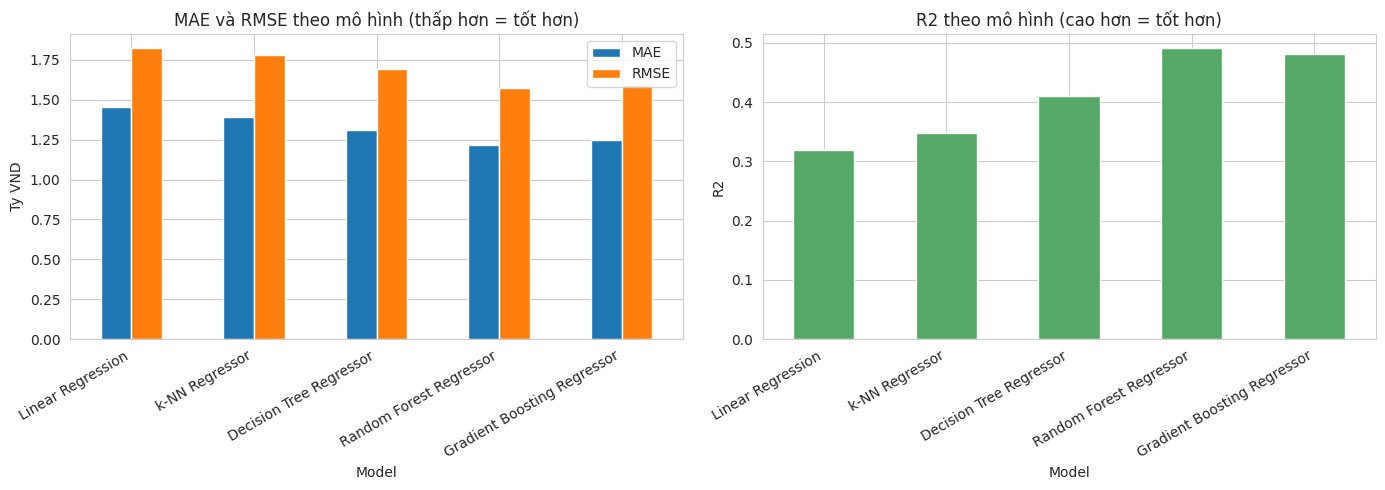

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
results_df[['MAE','RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('MAE và RMSE theo mô hình (thấp hơn = tốt hơn)')
axes[0].set_ylabel('Ty VND')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

results_df[['R2']].plot(kind='bar', ax=axes[1], color='#55A868', legend=False)
axes[1].set_title('R2 theo mô hình (cao hơn = tốt hơn)')
axes[1].set_ylabel('R2')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=110)
plt.show()


In [14]:
best_model_name = results_df['R2'].idxmax()
print(f"Mo hinh tot nhat theo R2: {best_model_name}")
print(results_df.loc[best_model_name])


Mo hinh tot nhat theo R2: Random Forest Regressor
MAE          1.2186
MSE          2.4835
RMSE         1.5759
R2           0.4906
MAPE (%)    26.5579
Name: Random Forest Regressor, dtype: float64


**Kết luận:** Dựa trên bảng so sánh, **Random Forest Regressor** (hoặc Gradient Boosting, tùy kết
quả chạy thực tế) đạt R² cao nhất và MAE/RMSE thấp nhất, cho thấy mô hình tổ hợp cây quyết định nắm bắt
tốt các mối quan hệ phi tuyến giữa diện tích, số phòng, khu vực và giá nhà — tốt hơn hồi quy tuyến tính
đơn giản. k-NN và Decision Tree đơn lẻ thường có hiệu suất thấp hơn do độ nhiễu cao trong dữ liệu bất
động sản (nhiều giá trị thiếu đã được điền, và giá còn phụ thuộc các yếu tố không có trong dữ liệu như vị
trí cụ thể, mặt phố kinh doanh, quy hoạch...).


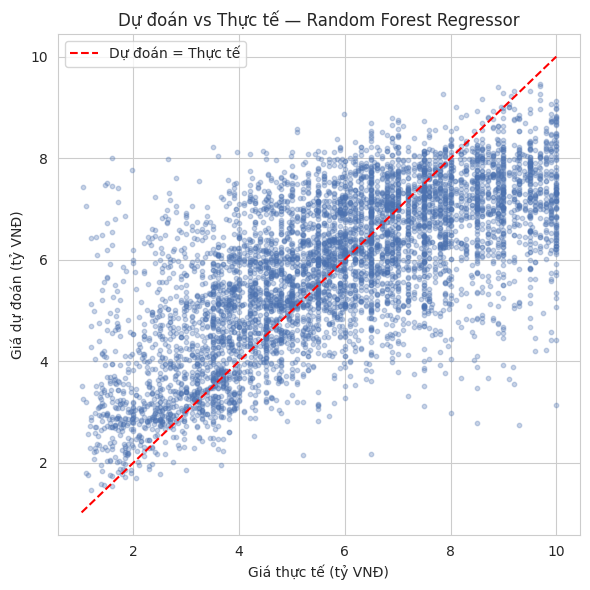

In [15]:
# Ve bieu do du doan vs thuc te cho mo hinh tot nhat
best_needs_scaling = models[best_model_name][1]
Xte_best = X_test_scaled if best_needs_scaling else X_test
y_pred_best = trained_models[best_model_name].predict(Xte_best)

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(y_test, y_pred_best, alpha=0.3, s=10, color='#4C72B0')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, 'r--', label='Dự đoán = Thực tế')
ax.set_xlabel('Giá thực tế (tỷ VNĐ)')
ax.set_ylabel('Giá dự đoán (tỷ VNĐ)')
ax.set_title(f'Dự đoán vs Thực tế — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.savefig('best_model_pred_vs_actual.png', dpi=110)
plt.show()


## 4. Triển khai mô hình

Huấn luyện lại mô hình tốt nhất trên toàn bộ dữ liệu (để tận dụng tối đa thông tin), lưu lại mô hình,
scaler (nếu cần), và danh sách cột đặc trưng để `app.py` có thể tái tạo đúng pipeline biểu diễn dữ liệu
khi nhận đầu vào mới.


In [16]:
import joblib

# Huan luyen lai mo hinh tot nhat tren toan bo du lieu
final_model_class = type(trained_models[best_model_name])
final_params = trained_models[best_model_name].get_params()
final_model = final_model_class(**final_params)

if best_needs_scaling:
    scaler_full = StandardScaler()
    X_full_scaled = scaler_full.fit_transform(X)
    final_model.fit(X_full_scaled, y)
else:
    scaler_full = None
    final_model.fit(X, y)

bundle = {
    'model': final_model,
    'model_name': best_model_name,
    'needs_scaling': best_needs_scaling,
    'scaler': scaler_full,
    'feature_columns': list(X.columns),
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'top_cities': list(top_cities),
}
joblib.dump(bundle, 'housing_price_model.joblib')
print("Da luu mo hinh vao housing_price_model.joblib")
print("Mo hinh trien khai:", best_model_name)


Da luu mo hinh vao housing_price_model.joblib
Mo hinh trien khai: Random Forest Regressor


In [17]:
# Kiem tra nhanh pipeline du doan cho 1 ngoi nha moi truoc khi viet app.py
def build_input_row(raw: dict, bundle: dict) -> pd.DataFrame:
    row = {c: raw.get(c, np.nan) for c in bundle['num_cols']}
    for c in bundle['num_cols']:
        if pd.isna(row[c]):
            row[c] = 0  # gia tri mac dinh don gian cho demo
    city = raw.get('city', 'Unknown')
    if city not in bundle['top_cities']:
        city = 'Khac'
    cat_raw = {
        'House direction': raw.get('House direction', 'Unknown'),
        'Balcony direction': raw.get('Balcony direction', 'Unknown'),
        'Legal status': raw.get('Legal status', 'Unknown'),
        'Furniture state': raw.get('Furniture state', 'Unknown'),
        'city': city,
    }
    full = {**row, **cat_raw}
    df_row = pd.DataFrame([full])
    df_row = pd.get_dummies(df_row, columns=['House direction','Balcony direction','Legal status','Furniture state','city'])
    df_row = df_row.reindex(columns=bundle['feature_columns'], fill_value=0)
    return df_row

sample = {
    'Area': 60, 'Frontage': 4.5, 'Access Road': 6, 'Floors': 3, 'Bedrooms': 3, 'Bathrooms': 3,
    'House direction': 'Đông - Nam', 'Balcony direction': 'Đông - Nam',
    'Legal status': 'Have certificate', 'Furniture state': 'Full', 'city': 'Hà Nội'
}
row = build_input_row(sample, bundle)
Xrow = bundle['scaler'].transform(row) if bundle['needs_scaling'] else row
pred = bundle['model'].predict(Xrow)[0]
print(f"Du doan gia nha mau: {pred:.2f} ty VND")


Du doan gia nha mau: 6.75 ty VND


Kết quả trên xác nhận pipeline hoạt động đúng — cùng logic này sẽ được đóng gói vào `app.py`
để trở thành một ứng dụng độc lập, có thể chạy ngoài notebook.
